# Penguin-VL Inference Recipes

This notebook mirrors the cases in `inference/example_penguinvl.py` and presents them in a notebook-friendly format that is easier to read on GitHub after execution.

## What This Notebook Covers

1. Generate Python code from a screenshot of an algorithm problem.
2. Parse a newspaper page with OCR-style prompting.
3. Produce creative writing from an artwork.
4. Convert a long table image into Markdown.
5. Run a multi-round chart-understanding conversation.
6. Run a multi-round video-understanding conversation.
7. Mix video and image inputs in a single prompt.
8. Compare with a plain-text-only prompt.

## Before You Run It

- Use the same Python environment that you use for `python inference/example_penguinvl.py`.
- `transformers==4.51.3` is recommended by the repo.
- Set `MODEL_PATH` below to a Hugging Face model ID or a local checkpoint.
- After running the notebook, save it so GitHub can render the outputs inline.


## General: Import Libraries and Locate the Repo

This cell keeps the notebook portable. It searches upward from the current working directory until it finds `inference/example_penguinvl.py`.


In [1]:
import os
import html
import base64
import mimetypes
import sys
import contextlib
import warnings
from pathlib import Path

os.environ.setdefault('CUDA_VISIBLE_DEVICES', '0')
os.environ.setdefault('HF_HUB_DISABLE_PROGRESS_BARS', '1')
os.environ.setdefault('TOKENIZERS_PARALLELISM', 'false')
os.environ.setdefault('TRANSFORMERS_VERBOSITY', 'error')

warnings.filterwarnings('ignore')

import torch
import markdown2
from IPython.display import HTML, Markdown, display
from transformers import AutoModelForCausalLM, AutoProcessor


def find_repo_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / 'inference' / 'example_penguinvl.py').exists():
            return path
    raise FileNotFoundError('Could not locate the Penguin-VL repo root from the current working directory.')


@contextlib.contextmanager
def suppress_output():
    with open(os.devnull, 'w') as devnull:
        stdout_fd = os.dup(1)
        stderr_fd = os.dup(2)
        try:
            with contextlib.redirect_stdout(devnull), contextlib.redirect_stderr(devnull):
                os.dup2(devnull.fileno(), 1)
                os.dup2(devnull.fileno(), 2)
                yield
        finally:
            os.dup2(stdout_fd, 1)
            os.close(stdout_fd)
            os.dup2(stderr_fd, 2)
            os.close(stderr_fd)


REPO_ROOT = find_repo_root(Path.cwd())
ASSETS_DIR = REPO_ROOT / 'assets' / 'inputs'
SCRIPT_PATH = REPO_ROOT / 'inference' / 'example_penguinvl.py'
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print('Located Penguin-VL repo assets successfully.')
print('Script target: inference/example_penguinvl.py')
print('Assets directory: assets/inputs')


Located Penguin-VL repo assets successfully.
Script target: inference/example_penguinvl.py
Assets directory: assets/inputs


## General: Load Model and Processor

This cell intentionally matches the loading logic in `inference/example_penguinvl.py` so the notebook stays aligned with the script.


In [2]:
MODEL_PATH = os.environ.get('PENGUIN_VL_MODEL_PATH', 'tencent/Penguin-VL-8B')
MODEL_LABEL = Path(MODEL_PATH).name if Path(MODEL_PATH).is_absolute() else MODEL_PATH
print('Using MODEL_PATH:', MODEL_LABEL)

with suppress_output():
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_PATH,
        trust_remote_code=True,
        device_map={'': 'cuda:0'},
        torch_dtype=torch.bfloat16,
        attn_implementation='flash_attention_2',
    )
    processor = AutoProcessor.from_pretrained(MODEL_PATH, trust_remote_code=True)

display(Markdown('_Model and processor loaded._'))


Using MODEL_PATH: tencent/Penguin-VL-8B


_Model and processor loaded._

## General: Notebook Helpers

The notebook rendering utilities are imported from `inference/notebooks/penguin_notebook_helpers.py`. The code cell below stays intentionally short so readers can focus on the examples instead of the UI plumbing.


In [3]:
from inference.notebooks.penguin_notebook_helpers import install_notebook_helpers

install_notebook_helpers(
    namespace=globals(),
    model=model,
    processor=processor,
    repo_root=REPO_ROOT,
    assets_dir=ASSETS_DIR,
    suppress_output=suppress_output,
)

display(Markdown('_Notebook helper utilities loaded._'))


_Notebook helper utilities loaded._

## Section 1: Single Image Understanding

This section mirrors the single-image examples in the Python script. Each case uses one image plus one user prompt.


### Example 1: Code Generation from an Algorithm Screenshot

**Input Image**


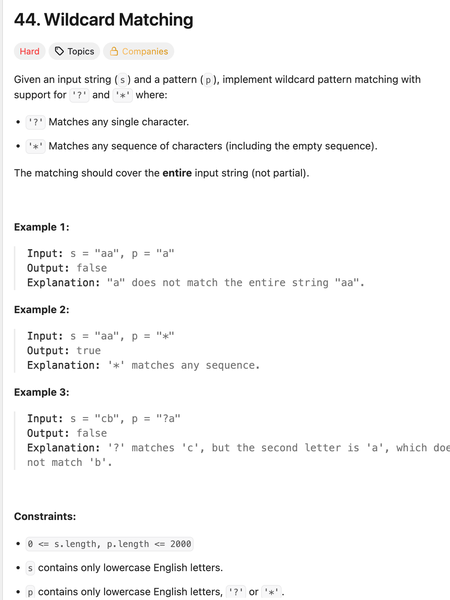

`assets/inputs/leetcode.png`

**Question**

> please think this problem step by step and give the python code solution

**Model Response**

To solve the wildcard matching problem, we can use dynamic programming. The idea is to create a 2D DP table where `dp[i][j]` represents whether the first `i` characters of the string `s` match the first `j` characters of the pattern `p`.

### Step-by-Step Approach:

1. **Initialization**:
   - Create a 2D DP table with dimensions `(len(s) + 1) x (len(p) + 1)`.
   - Initialize `dp[0][0]` to `True` because an empty string matches an empty pattern.
   - Initialize the first row (`dp[0][j]`) to `True` if the pattern up to `j` consists of only `*` characters, because `*` can match an empty string.

2. **Filling the DP Table**:
   - For each cell `dp[i][j]`:
     - If `p[j-1]` is a regular character, it matches `s[i-1]` if `p[j-1] == s[i-1]` and `dp[i-1][j-1]` is `True`.
     - If `p[j-1]` is `?`, it matches `s[i-1]` if `dp[i-1][j-1]` is `True`.
     - If `p[j-1]` is `*`, it can match zero or more characters:
       - It can match zero characters by considering `dp[i][j-1]`.
       - It can match one or more characters by considering `dp[i-1][j]` if `s[i-1]` matches the character before `*` in the pattern.

3. **Result**:
   - The value at `dp[len(s)][len(p)]` will be the result, indicating whether the entire string `s` matches the pattern `p`.

### Python Code Solution:

```python
def isMatch(s: str, p: str) -> bool:
    m, n = len(s), len(p)
    dp = [[False] * (n + 1) for _ in range(m + 1)]
    dp[0][0] = True
    
    # Initialize the first row for patterns with *
    for j in range(1, n + 1):
        if p[j - 1] == '*':
            dp[0][j] = dp[0][j - 1]
    
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if p[j - 1] == '*':
                dp[i][j] = dp[i][j - 1] or dp[i - 1][j]
            elif p[j - 1] == '?' or s[i - 1] == p[j - 1]:
                dp[i][j] = dp[i - 1][j - 1]
    
    return dp[m][n]
```

### Explanation of the Code:

- **Initialization**:
  - `dp[0][0]` is set to `True` because an empty string matches an empty pattern.
  - The first row is initialized to handle patterns that consist of only `*` characters.

- **Filling the DP Table**:
  - For each cell, we check the current character in the pattern:
    - If it's `*`, we consider both the case where it matches zero characters and the case where it matches one or more characters.
    - If it's `?`, it matches any character, so we check the previous cell.
    - If it's a regular character, it matches if the current characters in `s` and `p` are the same and the previous cells match.

- **Result**:
  - The final result is stored in `dp[m][n]`, which indicates whether the entire string `s` matches the pattern `p`.

This solution has a time complexity of O(m * n) and a space complexity of O(m * n), where `m` and `n` are the lengths of the string `s` and the pattern `p`, respectively.

---

In [4]:
leetcode_response = run_single_image_case(
    title='Example 1: Code Generation from an Algorithm Screenshot',
    image_name='leetcode.png',
    question='please think this problem step by step and give the python code solution',
)


### Example 2: OCR-Style Parsing from a Newspaper Page

**Input Image**


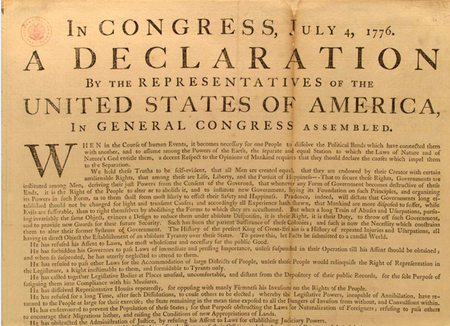

`assets/inputs/newspaper.png`

**Question**

> please output the text in the image

**Model Response**

> Here is the parsed text content from the image, organized from left to right and top to bottom:
>
> ---
>
> **IN CONGRESS, JULY 4, 1776.**
>
> **A DECLARATION**
>
> **BY THE REPRESENTATIVES OF THE**
>
> **UNITED STATES OF AMERICA,**
>
> **IN GENERAL CONGRESS ASSEMBLED.**
>
> ---
>
> **W**HEN in the Course of human Events, it becomes necessary for one People to dissolve the Political Bands which have connected them with another, and to assume among the Powers of the Earth, the separate and equal Station to which the Laws of Nature and of Nature&#x27;s God entitle them, a decent Respect to the Opinions of Mankind requires that they should declare the causes which impel them to the Separation.
>
> We hold these Truths to be self-evident, that all Men are created equal, that they are endowed by their Creator with certain unalienable Rights, that among these are Life, Liberty, and the Pursuit of Happiness—That to secure these Rights, Governments are instituted among Men, deriving their just Powers from the Consent of the Governed, that whenever any Form of Government becomes destructive of these Ends, it is the Right of the People to alter or to abolish it, and to institute new Government, laying its Foundation on such Principles, and organizing its Powers in such Form, as to them shall seem most likely to effect their Safety and Happiness. Prudence, indeed, will dictate that Governments long established should not be changed for light and transient Causes; and accordingly all Experience hath shewn, that Mankind are more disposed to suffer, while Evils are sufferable, than to right themselves by abolishing the Forms to which they are accustomed. But when a long Train of Abuses and Usurpations, pursuing invariably the same Object, evinces a Design to reduce them under absolute Despotism, it is their Right, it is their Duty, to throw off such Government, and to provide new Guards for their future Security. Such has been the patient Sufferance of these Colonies; and such is now the Necessity which constrains them to alter their former Systems of Government. The History of the present King of Great Britain is a History of repeated Injuries and Usurpations, all having in direct Object the Establishment of an absolute Tyranny over these States. To prove this, let Facts be submitted to a candid World.
>
> He has refused his Assent to Laws, the most wholesome and necessary for the public Good.
>
> He has forbidden his Governors to pass Laws of immediate and pressing Importance, unless suspended in their Operation till his Assent should be obtained, and when so suspended, he has utterly neglected to attend to them.
>
> He has refused to pass other Laws for the Accommodation of large Districts of People, unless those People would relinquish the Right of Representation in the Legislature, a Right inestimable to them, and formidable to Tyrants only.
>
> He has called together Legislative Bodies at Places unusual, uncomfortable, and distant from the Depository of their public Records, for the sole Purpose of fatiguing them into Compliance with his Measures.
>
> He has dissolved Representative Houses repeatedly, for opposing with manly Firmness his Invasions on the Rights of the People.
>
> He has refused for a long Time, after such Dissolutions, to cause others to be elected; whereby the Legislative Powers, incapable of Annihilation, have returned to the People at large for their exercise; the State remaining in the mean time exposed to all the Hangers of Invasion from without, and Convulsions within.
>
> He has endeavoured to prevent the Population of these States; for that Purpose obstructing the Laws for Naturalization of Foreigners; refusing to pass others to encourage their Migrations hither, and raising the Conditions of new Appropriations of Lands.
>
> He has obstructed the Administration of Justice, by refusing his Assent to Laws for establishing Judiciary Powers.
>
> ---
>
> This text is the **Declaration of Independence** of the United States, adopted by the Continental Congress on July 4, 1776. It outlines the reasons for the colonies&#x27; decision to declare independence from Great Britain.

---

In [5]:
ocr_response = run_single_image_case(
    title='Example 2: OCR-Style Parsing from a Newspaper Page',
    image_name='newspaper.png',
    question='please output the text in the image',
)


### Example 3: Creative Writing from an Artwork

**Input Image**


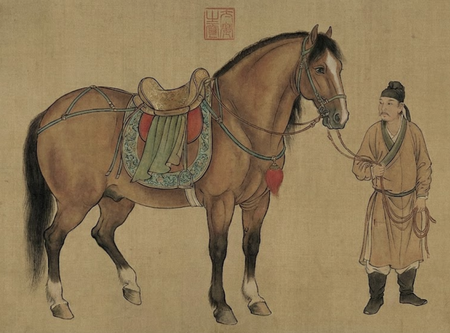

`assets/inputs/horse_poet.png`

**Question**

> Write a short poem inspired by this image. Capture the relationship between the man and the horse, as well as the traditional, historical atmosphere of the painting.

**Model Response**

> In ancient times, where history whispers low,  
> A man and horse stand, a bond they show.  
> The man, with robes of earth and sky,  
> Holds the reins, a gentle, guiding eye.  
>
> The horse, a steed of noble grace,  
> Its harness adorned with art and space.  
> Its eyes, like windows to the soul,  
> Reflect the trust that makes them whole.  
>
> The man’s hand steady, firm yet kind,  
> The horse’s spirit, calm and aligned.  
> Together they stand, a silent tale,  
> Of partnership, strength, and gentle hail.  
>
> The brushstrokes soft, the colors deep,  
> A world of tradition, history’s keep.  
> In this still moment, time stands still,  
> A bond unbroken, a story to fulfill.

---

In [6]:
poem_response = run_single_image_case(
    title='Example 3: Creative Writing from an Artwork',
    image_name='horse_poet.png',
    question='Write a short poem inspired by this image. Capture the relationship between the man and the horse, as well as the traditional, historical atmosphere of the painting.',
)


### Example 4: Long Table Parsing to Markdown

**Input Image**


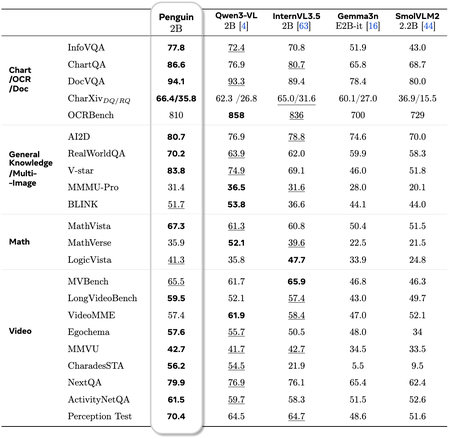

`assets/inputs/2b_table_result.png`

**Question**

> please output the table content in markdown format.

**Model Response**

Here is the table content in markdown format:

```markdown
| Chart/OCR/Doc | Penguin 2B | Qwen3-VL 2B [4] | InternVL3.5 2B [63] | Gemma3n E2B-it [16] | SmolVLM2 2.2B [44] |
|---------------|------------|-----------------|---------------------|---------------------|--------------------|
| InfoVQA       | 77.8       | 72.4            | 70.8                | 51.9                | 43.0               |
| ChartQA       | 86.6       | 76.9            | 80.7                | 65.8                | 68.7               |
| DocVQA        | 94.1       | 93.3            | 89.4                | 78.4                | 80.0               |
| CharXiv_DQ/RQ | 66.4/35.8  | 62.3/26.8       | 65.0/31.6           | 60.1/27.0           | 36.9/15.5          |
| OCRBench      | 810        | 858             | 836                 | 700                 | 729                |

| General Knowledge/Multi-Image | Penguin 2B | Qwen3-VL 2B [4] | InternVL3.5 2B [63] | Gemma3n E2B-it [16] | SmolVLM2 2.2B [44] |
|-------------------------------|------------|-----------------|---------------------|---------------------|--------------------|
| AI2D                          | 80.7       | 76.9            | 78.8                | 74.6                | 70.0               |
| RealWorldQA                   | 70.2       | 63.9            | 62.0                | 59.9                | 58.3               |
| V-star                        | 83.8       | 74.9            | 69.1                | 46.0                | 51.8               |
| MMMU-Pro                      | 31.4       | 36.5            | 31.6                | 28.0                | 20.1               |
| BLINK                         | 51.7       | 53.8            | 36.6                | 44.1                | 44.0               |

| Math                          | Penguin 2B | Qwen3-VL 2B [4] | InternVL3.5 2B [63] | Gemma3n E2B-it [16] | SmolVLM2 2.2B [44] |
|-------------------------------|------------|-----------------|---------------------|---------------------|--------------------|
| MathVista                     | 67.3       | 61.3            | 60.8                | 50.4                | 51.5               |
| MathVerse                     | 35.9       | 52.1            | 39.6                | 22.5                | 21.5               |
| LogicVista                    | 41.3       | 35.8            | 47.7                | 33.9                | 24.8               |

| Video                         | Penguin 2B | Qwen3-VL 2B [4] | InternVL3.5 2B [63] | Gemma3n E2B-it [16] | SmolVLM2 2.2B [44] |
|-------------------------------|------------|-----------------|---------------------|---------------------|--------------------|
| MVBench                       | 65.5       | 61.7            | 65.9                | 46.8                | 46.3               |
| LongVideoBench                | 59.5       | 52.1            | 57.4                | 43.0                | 49.7               |
| VideoMME                      | 57.4       | 61.9            | 58.4                | 47.0                | 52.1               |
| Egochema                      | 57.6       | 55.7            | 50.5                | 48.0                | 34                 |
| MMVU                          | 42.7       | 41.7            | 42.7                | 34.5                | 33.5               |
| CharadesSTA                   | 56.2       | 54.5            | 21.9                | 5.5                 | 9.5                |
| NextQA                        | 79.9       | 76.9            | 76.1                | 65.4                | 62.4               |
| ActivityNetQA                 | 61.5       | 59.7            | 58.3                | 51.5                | 52.6               |
| Perception Test               | 70.4       | 64.5            | 64.7                | 48.6                | 51.6               |
```

---

In [7]:
table_response = run_single_image_case(
    title='Example 4: Long Table Parsing to Markdown',
    image_name='2b_table_result.png',
    question='please output the table content in markdown format.',
)


## Section 2: Multi-Round Chart Understanding

This case demonstrates how to carry conversation history forward. The image is only attached in round 1; later rounds rely on the stored assistant context.


### Example 5: Multi-Round Chart Understanding

**Input Image**


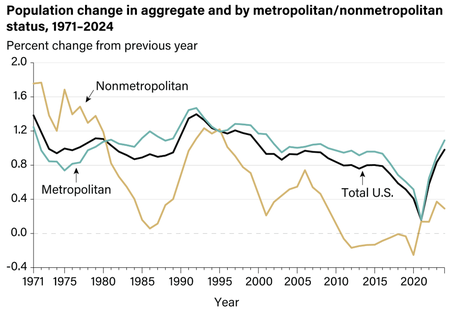

`assets/inputs/chart_understanding.png`

**Question**

> Look at the &#x27;Nonmetropolitan&#x27; line. In what approximate year does it reach its absolute lowest point on the chart, and what is the approximate percent change at that time?

**Round 1 Response**

> The &#x27;Nonmetropolitan&#x27; line reaches its absolute lowest point on the chart around the year 2020. The approximate percent change at that time is around -0.2%.

---

**Question**

> Compare the three lines over the entire 50-year period. Which demographic category exhibits the highest volatility (the most dramatic peaks and valleys), and which one appears to be the most stable?

**Round 2 Response**

> Over the entire 50-year period, the &#x27;Nonmetropolitan&#x27; line exhibits the highest volatility, with the most dramatic peaks and valleys. The &#x27;Total U.S.&#x27; line appears to be the most stable, with less dramatic fluctuations.

---

In [8]:
chart_answers = run_multiround_image_case(
    title='Example 5: Multi-Round Chart Understanding',
    image_name='chart_understanding.png',
    questions=[
        "Look at the 'Nonmetropolitan' line. In what approximate year does it reach its absolute lowest point on the chart, and what is the approximate percent change at that time?",
        'Compare the three lines over the entire 50-year period. Which demographic category exhibits the highest volatility (the most dramatic peaks and valleys), and which one appears to be the most stable?',
    ],
)


## Section 3: Multi-Round Video Understanding

This case mirrors the multi-round video example in the script. The notebook records the prompt sequence and each generated answer while keeping the video display lightweight for GitHub.


In [9]:
video_answers = run_multiround_video_case(
    title='Example 6: Multi-Round Video Understanding',
    video_name='video-example.mp4',
    questions=[
        'please describe the video in details',
        'At what timestamps is the Summar Palace mentioned?',
        'At what timestamps is the CHANG AN AVENUE mentioned?',
        'At what timestamps is the THE FINANCIAL STREET FORUM mentioned?',
    ],
    fps=1,
    max_frames=180,
)


### Example 6: Multi-Round Video Understanding

**Input Video**

`video-example.mp4`

- Source: `assets/inputs/video-example.mp4`
- FPS: `1`
- Max Frames: `180`

**Question**

> please describe the video in details

**Round 1 Response**

> This video presents a sweeping visual narrative of Beijing, masterfully contrasting its ancient imperial heritage with its modern, dynamic identity. The core narrative follows a journey of discovery, beginning with a reverent exploration of the city&#x27;s historical landmarks, such as the Forbidden City, the Temple of Heaven, and the Great Wall, which are presented as symbols of a long and profound history. The video&#x27;s structure is deliberately paced, using slow, majestic shots to establish a sense of awe and timelessness. This initial phase is designed to take the viewer on an emotional journey of wonder, appreciating the grandeur of the past. The progression of the city itself is the central theme, as it transforms from a historical monument into a vibrant, contemporary metropolis. The narrative pivots dramatically, shifting to a fast-paced montage of modern life: sleek skyscrapers, bustling streets, high-speed trains, and a diverse array of cultural and technological attractions. This structural shift in pacing mirrors the city&#x27;s evolution, moving from the contemplative to the energetic. Key visual motifs, such as the juxtaposition of traditional architecture with modern glass and steel, and the recurring text &#x27;THIS IS BEIJING,&#x27; reinforce the central theme of duality. The video&#x27;s final takeaway is a powerful statement about Beijing&#x27;s identity: it is not a city of the past, but a city of the future, where history and modernity coexist to create a unique and globally significant urban experience.

---

**Question**

> At what timestamps is the Summar Palace mentioned?

**Round 2 Response**

> During the period 36.00 - 39.99 seconds .

---

**Question**

> At what timestamps is the CHANG AN AVENUE mentioned?

**Round 3 Response**

> During the period 206.00 - 208.00 seconds .

---

**Question**

> At what timestamps is the THE FINANCIAL STREET FORUM mentioned?

**Round 4 Response**

> During the period 277.99 - 280.00 seconds .

---

## Section 4: Mixed-Modal Prompting

This example combines a video and an image in one user turn, then asks the model to produce a single creative response.


### Example 7: Mixed Video + Image Story Generation

**Input Video**

`polar_bear.mp4`

- Source: `assets/inputs/polar_bear.mp4`
- FPS: `1`
- Max Frames: `180`

**Reference Image**


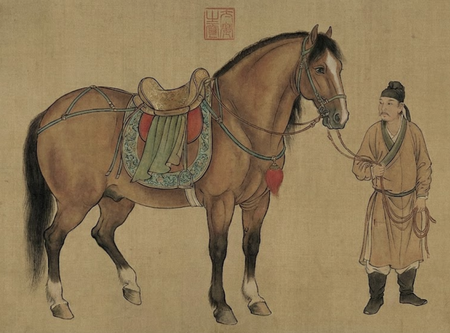

`assets/inputs/horse_poet.png`

**Question**

> Write a fairy tale based on the video and the image below:\nVideo\n

**Model Response**

> Once upon a time, in a land far, far away, there was a majestic polar bear named Paws. Paws lived in a vast, snowy tundra, where the only other creature he knew was his best friend, a young polar bear cub named Cubby. They spent their days playing in the snow, chasing each other around, and exploring the frozen landscape.
>
> One day, Paws and Cubby stumbled upon a strange, ancient painting. The painting depicted a man and a horse, both adorned in elaborate, colorful garments. Paws was intrigued by the painting and decided to investigate further. He followed the trail of the painting, which led him to a hidden cave.
>
> Inside the cave, Paws found a treasure trove of ancient artifacts. There were golden coins, precious jewels, and even a magical amulet. Paws was overjoyed and decided to take the amulet with him. He knew that this amulet would help him protect Cubby and their home from any danger.
>
> Paws and Cubby returned to their home, where they used the amulet to defend themselves against a group of hungry wolves. The amulet glowed brightly, and the wolves were repelled. Paws and Cubby were safe, and they knew that they could always count on the amulet to protect them.
>
> From that day on, Paws and Cubby lived happily ever after, with the amulet as their trusted companion. They continued to explore the tundra, always ready to face any challenge that came their way. And they lived happily ever after.

---

In [10]:
mixed_response = run_mixed_case(
        title='Example 7: Mixed Video + Image Story Generation',
        video_name='polar_bear.mp4',
        image_name='horse_poet.png',
        question='Write a fairy tale based on the video and the image below:\\nVideo\\n',
        fps=1,
        max_frames=180,
    )


## Section 5: Text-Only Baseline

A plain-text example is useful as a minimal baseline when you want to compare multimodal behavior against a standard chat prompt.


In [11]:
text_response = run_text_case(
    title='Example 8: Plain Text Conversation',
    question='There are ten birds in a tree. If you shoot and kill one, how many are left?',
)


### Example 8: Plain Text Conversation

**Question**

> There are ten birds in a tree. If you shoot and kill one, how many are left?

**Model Response**

> None, because the sound of the gunshot would scare all the birds away.

---

## Optional Appendix: Capture the Raw Script Output

The cells above are the notebook-friendly version of the examples. If you also want exact terminal parity with `python3 inference/example_penguinvl.py`, run the next cell. It will launch the script in a subprocess and print the raw stdout and stderr.

Note: this loads the model again, so it is slower and uses additional GPU memory while it runs.


In [12]:
RUN_RAW_SCRIPT_APPENDIX = False

if RUN_RAW_SCRIPT_APPENDIX:
    import subprocess

    cmd = [
        'python3',
        'inference/example_penguinvl.py',
        '--model-path',
        MODEL_PATH,
    ]

    result = subprocess.run(
        cmd,
        cwd=REPO_ROOT,
        capture_output=True,
        text=True,
        check=False,
    )

    print('Return code:', result.returncode)
    print('\n=== STDOUT ===\n')
    print(result.stdout)
    print('\n=== STDERR ===\n')
    print(result.stderr)
else:
    print('Skipping raw script appendix. Set RUN_RAW_SCRIPT_APPENDIX = True to enable it.')


Skipping raw script appendix. Set RUN_RAW_SCRIPT_APPENDIX = True to enable it.


## Optional: How to Execute This Notebook from the Terminal

From the repo root, you can either open it interactively:

```bash
jupyter lab
```

or execute it in-place so the outputs are saved for GitHub rendering:

```bash
jupyter nbconvert --to notebook --execute --inplace inference/notebooks/01_penguinvl_inference_recipes.ipynb
```

If you use a custom environment or launcher, make sure the notebook kernel points to the same environment that successfully runs `python inference/example_penguinvl.py`.
